# Task 1: Linear Regression Model for House Price Prediction

## Objective

The objective of this project is to build a Linear Regression model using the California Housing dataset. The project demonstrates the basic machine learning workflow, including data loading, data exploration, visualization, model training, prediction, evaluation, and saving the trained model.

## Importing Required Libraries

The following libraries are required for data analysis, visualization, model development, evaluation, and saving the trained model.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# Set plot style
sns.set(style="whitegrid")

## Loading the Dataset

The California Housing dataset is loaded from Scikit-learn. It contains information about housing districts in California along with the median house value, which will be used as the target variable.

In [2]:
# Load the dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["HousePrice"] = housing.target

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Understanding the Dataset

Before building the model, it is important to understand the size and structure of the dataset.

In [3]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Statistical Summary

The statistical summary provides information such as the mean, standard deviation, minimum, maximum, and quartiles for each numerical feature.

In [4]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Checking for Missing Values

Missing values can affect the performance of a machine learning model. This step checks whether the dataset contains any null values.

In [5]:
# Check missing values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

## Checking for Duplicate Records

Duplicate records can lead to biased model training. This step checks whether duplicate rows are present in the dataset.

In [6]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Displaying Sample Records

Viewing a few records from the dataset helps verify that the data has been loaded correctly and provides a better understanding of the available features.

In [7]:
# Display random sample records
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
15244,4.7841,31.0,5.975610,1.088692,1059.0,2.348115,33.00,-117.26,3.93500
12323,3.5208,20.0,5.200000,1.340000,69.0,1.380000,34.00,-116.57,0.76600
20389,10.0595,26.0,8.692308,1.076923,573.0,3.148352,34.19,-118.90,5.00001
18478,4.9028,14.0,6.372152,1.008861,2124.0,2.688608,37.10,-121.63,3.35000
2615,2.9600,19.0,5.070175,1.067251,866.0,2.532164,40.95,-124.11,0.81700


## Data Visualization

Data visualization helps in understanding the distribution of the data and the relationships between different features. It also helps identify patterns, trends, and possible outliers before training the machine learning model.

### Distribution of Features

Histograms are used to understand how the values of each feature are distributed across the dataset.

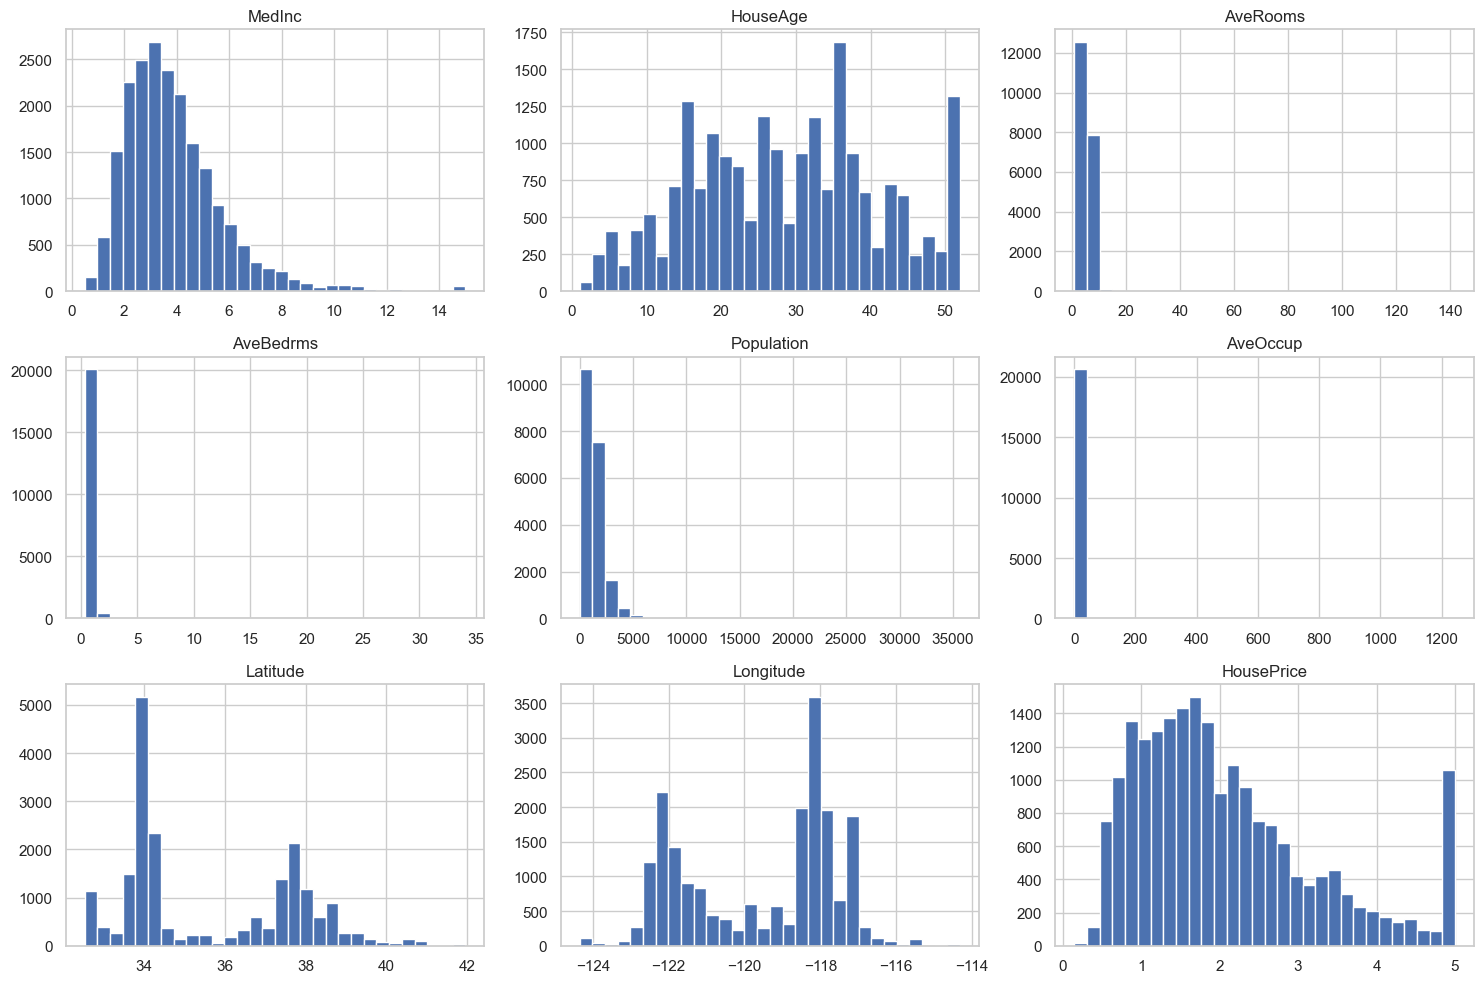

In [8]:
# Display histograms for all numerical features
df.hist(figsize=(15, 10), bins=30)

# Adjust spacing between plots
plt.tight_layout()

# Show the plots
plt.show()

### Correlation Heatmap

The correlation heatmap shows the relationship between different features in the dataset. Correlation values range from -1 to 1, where values closer to 1 or -1 indicate a stronger relationship.

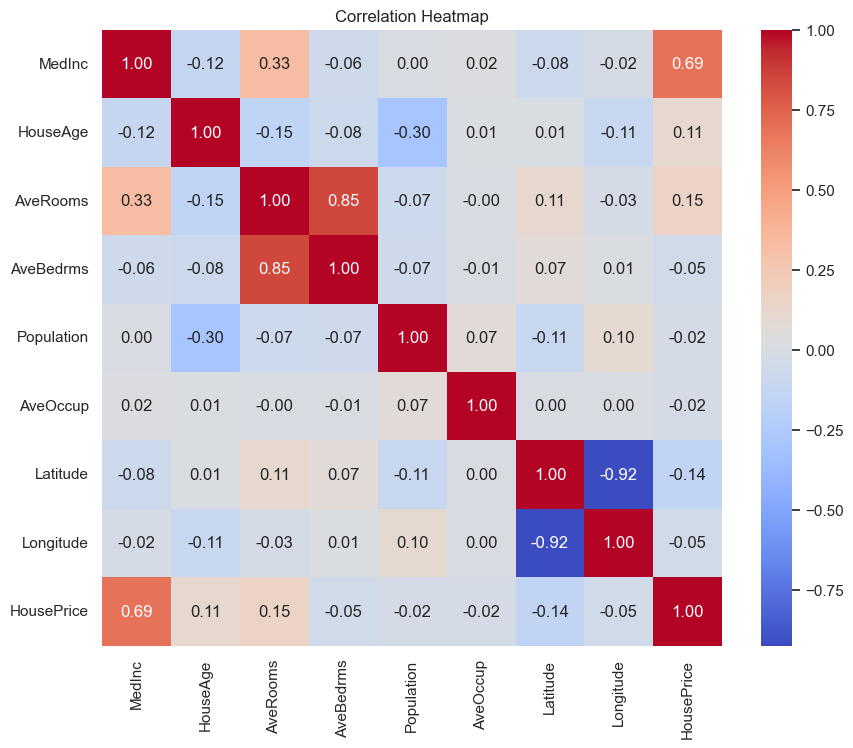

In [9]:
# Create a correlation matrix
correlation = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Relationship Between Median Income and House Price

This scatter plot helps visualize the relationship between the median income of a district and its corresponding house price.

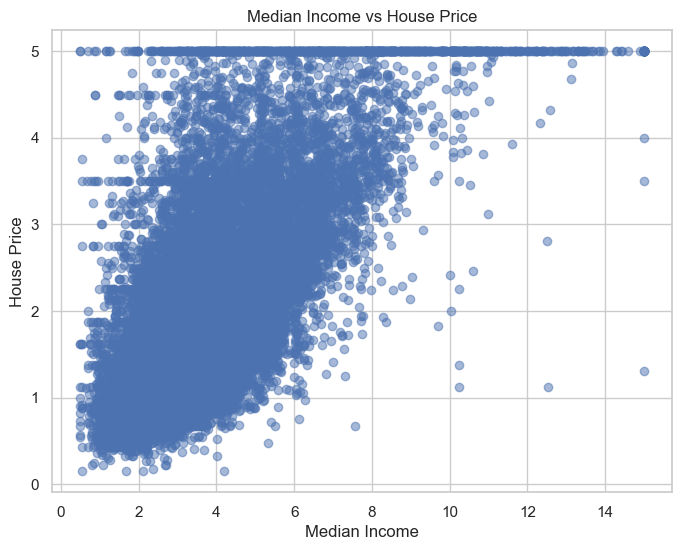

In [10]:
# Scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df["MedInc"],
    df["HousePrice"],
    alpha=0.5
)

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")

plt.show()

### Pair Plot

A pair plot provides a visual comparison between selected features. It helps identify relationships and patterns among variables.

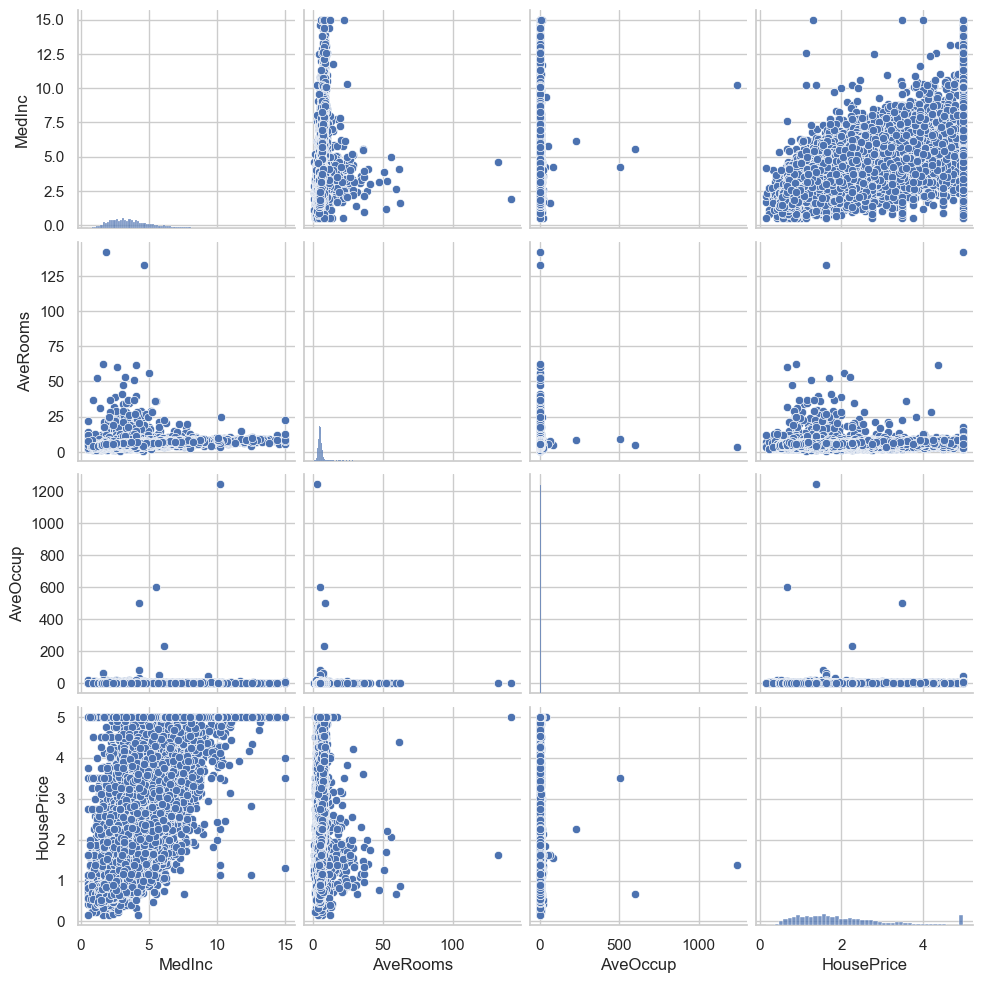

In [11]:
# Select important columns
selected_columns = [
    "MedInc",
    "AveRooms",
    "AveOccup",
    "HousePrice"
]

sns.pairplot(df[selected_columns])

plt.show()

### Box Plot

Box plots are used to identify the spread of the data and detect possible outliers in the numerical features.

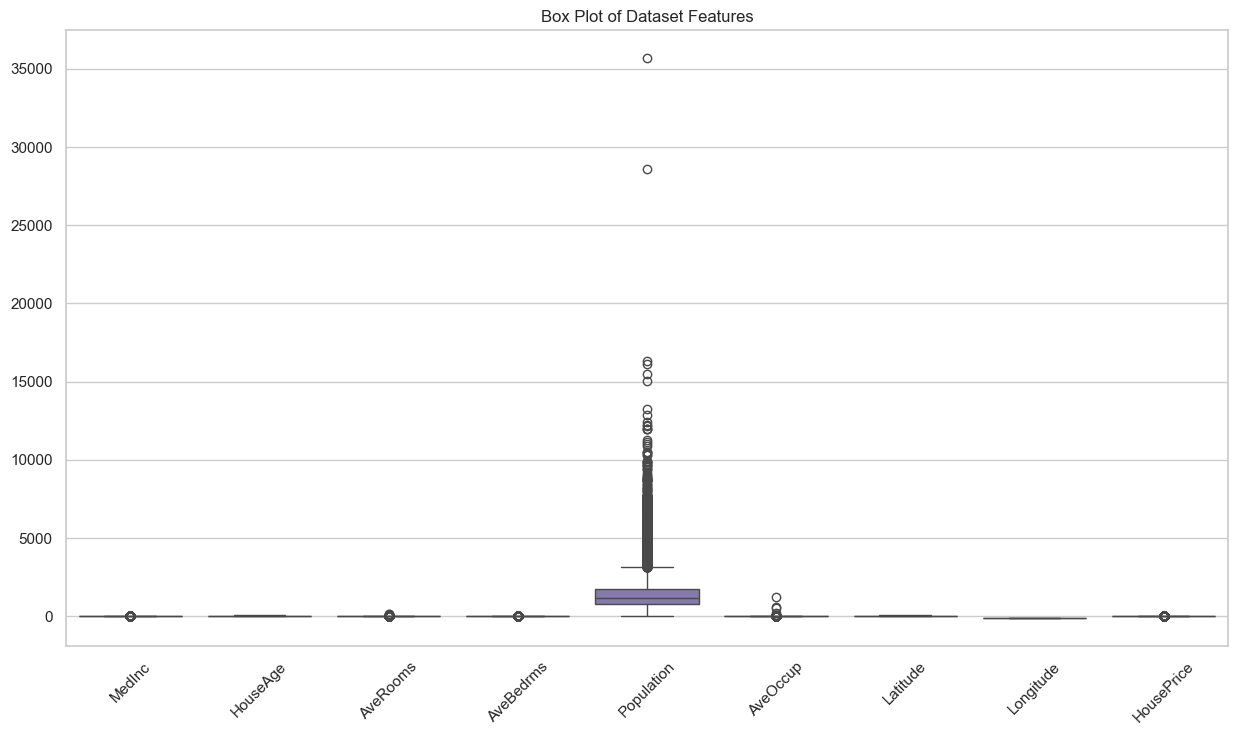

In [12]:
# Plot boxplots for all numerical columns
plt.figure(figsize=(15, 8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Box Plot of Dataset Features")

plt.show()

## Preparing the Data

Before training the model, the dataset is divided into features (input variables) and the target variable (output). The features are used by the model to predict the target value.

In [13]:
# Separate the features and target variable
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Display the shape of features and target
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


## Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [14]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the split datasets
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (16512, 8)
Testing Features : (4128, 8)
Training Target  : (16512,)
Testing Target   : (4128,)


## Training the Linear Regression Model

A Linear Regression model is created and trained using the training dataset. During training, the model learns the relationship between the input features and the target variable.

In [15]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Making Predictions

After training, the model is used to predict house prices for the testing dataset. These predictions will be compared with the actual values to evaluate the model.

In [16]:
# Predict house prices
y_pred = model.predict(X_test)

# Display the first 10 predictions
predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Comparing Actual and Predicted Values

The table below compares the actual house prices with the values predicted by the model. This provides a quick overview of the model's prediction performance.

In [17]:
# Display a comparison of actual and predicted values
predictions.sample(10)

,Actual Price,Predicted Price
560,4.714,2.603804
2803,0.582,0.418075
2331,2.380,2.199405
1916,1.781,1.476901
2184,1.163,-0.543611
3087,4.037,2.772948
204,1.521,2.413947
127,2.317,1.937717
974,2.147,1.452115
1491,1.114,1.485401


## Evaluating the Model

After training the Linear Regression model, its performance is evaluated using three commonly used regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine how accurately the model predicts house prices.

In [18]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the results
print("Model Evaluation Results")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------------
Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


## Actual vs Predicted Values

The following graph compares the actual house prices with the predicted values generated by the Linear Regression model.

A good model will produce points that are close to the diagonal line.

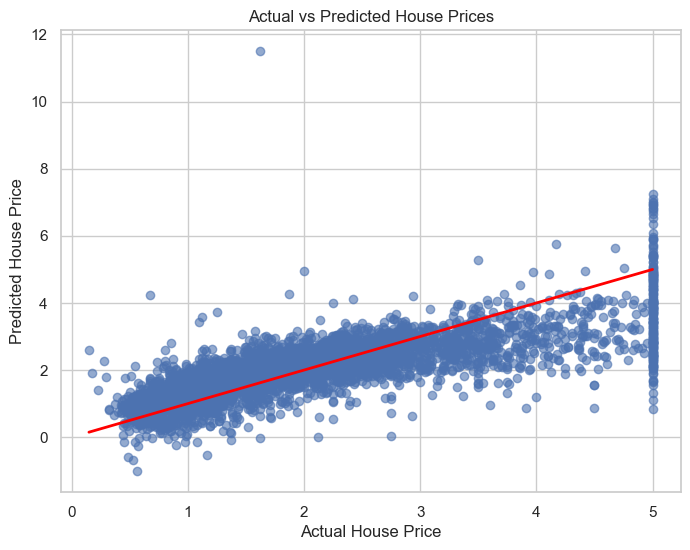

In [19]:
# Plot Actual vs Predicted values
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Model Coefficients

Linear Regression assigns a coefficient to each feature. These coefficients indicate how each feature influences the predicted house price.

In [20]:
# Display feature coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


## Saving the Trained Model

The trained model is saved so that it can be used later without retraining.

In [21]:
# Save the trained model
joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully.")

Model saved successfully.


## Loading the Saved Model

The saved model can be loaded and used to make predictions without training it again.

In [22]:
# Load the saved model
loaded_model = joblib.load("house_price_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


# Conclusion

In this project, a Linear Regression model was developed using the California Housing dataset.

The dataset was explored through statistical analysis and visualizations before preparing it for model training. The model was trained using the training dataset and evaluated using MAE, RMSE, and R² Score.

The results show that Linear Regression can be used to predict house prices with a reasonable level of accuracy. Future improvements could include feature engineering and experimenting with more advanced regression algorithms to improve prediction performance.